In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("AirPassengers.csv", parse_dates=["Month"], index_col="Month")
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [5]:
model = ExponentialSmoothing(
    df["#Passengers"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
    
)
model_fit = model.fit()
forecast_steps = 36
forecast = model_fit.forecast(forecast_steps)

C:\Users\Elabor Emmanuel\torch_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


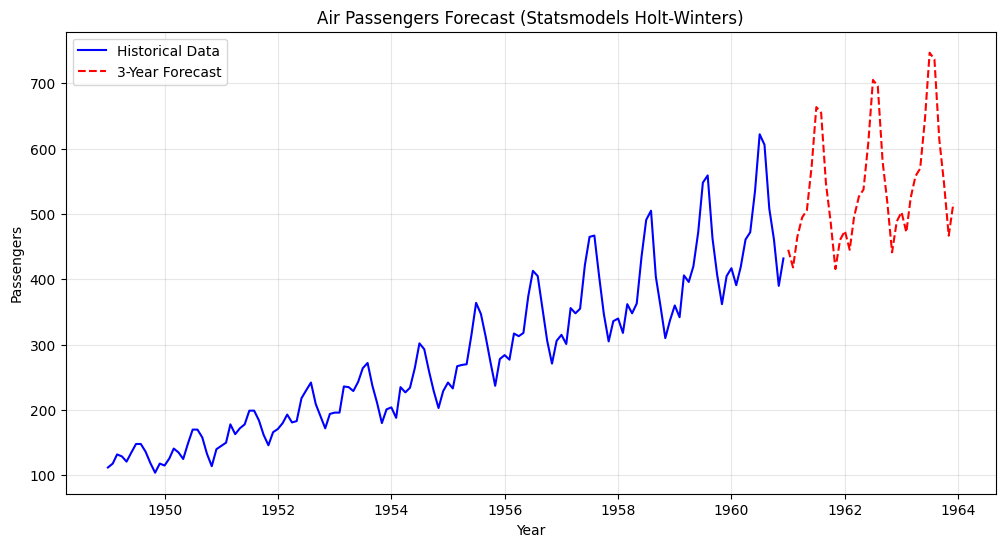

1961-01-01    445.242405
1961-02-01    418.225357
1961-03-01    465.309720
1961-04-01    494.951215
1961-05-01    505.475857
Freq: MS, dtype: float64


In [6]:
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(df.index, df['#Passengers'], label='Historical Data', color='blue')

# Plot the forecast
plt.plot(forecast.index, forecast, label='3-Year Forecast', color='red', linestyle='--')

plt.title('Air Passengers Forecast (Statsmodels Holt-Winters)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Optional: Print the forecast values
print(forecast.head())